# RunPod GPU Pod 생성과 Jupyter Notebook 시작하기

**RunPod**는 GPU가 연결된 원격 Linux 컨테이너를 필요한 시간만 임대해서 사용하는 실행 환경이다. 로컬 컴퓨터에 충분한 VRAM이 없을 때 모델 다운로드, 추론과 파인튜닝을 원격 GPU에서 수행하는 데 사용한다.

이 노트북에서는 GPU·template·storage를 선택해 Pod를 만들고, RunPod JupyterLab에 접속해 첫 Notebook을 작성한다. 마지막에는 원격 Python과 CUDA를 확인하고 Stop·Terminate의 파일 보존 및 비용 차이를 정리한다. SSH와 PyCharm 연결은 다음 노트북에서 별도로 다룬다.


z## Pod와 storage 선택하기

**Pod**는 JupyterLab로 직접 접속해 개발하고 학습하는 전용 실행 환경이다. **Serverless**는 요청이 들어올 때 worker가 실행되어 API 추론을 제공하는 배포 환경이다. 이번 실습은 대화형 디버깅과 GPU 확인이 필요하므로 Pod가 적합하다.

첫 실습은 갑작스러운 회수 위험이 없는 On-Demand Pod와 공식 PyTorch template을 우선한다. GPU 가격과 가용성은 시점·지역에 따라 달라지므로 고정 가격을 외우지 않고 실습 당일 배포 화면에서 확인한다.

Pod 생성 화면에서는 다음 순서로 확인한다.

1. `Pods → Deploy`에서 On-Demand GPU를 선택한다.
2. RunPod 공식 PyTorch template과 필요한 CUDA·Python version을 확인한다.
3. 실습 자료와 모델 cache가 들어갈 Volume disk 크기를 정한다.
4. JupyterLab을 사용할 수 있도록 HTTP service 설정을 확인한다.
5. 배포 후 Pod 상태가 `Running`이고 `Connect` 버튼이 활성화되는지 확인한다.

### Cloud와 GPU 제공 방식

- **Secure Cloud**: 데이터센터 기반의 신뢰성·보안 요구가 있는 작업에서 우선 검토한다. GPU 종류·지역과 조직의 보안 정책을 함께 확인한다.
- **Community Cloud**: 검증된 분산 공급자의 GPU를 사용해 선택 폭과 가격 경쟁력을 제공한다. 공개 데이터 기반 학습처럼 비용이 중요한 개발 작업에 적합하며 host별 가용성과 성능 차이를 고려한다.
- **On-Demand**: 사용자가 중지할 때까지 유지되는 비중단형 자원이다. Jupyter 실습·디버깅처럼 갑작스러운 회수가 곤란한 첫 실습에 적합하다.
- **Spot**: 남는 GPU를 할인된 가격으로 사용하지만 수요에 따라 회수될 수 있다. 자동 checkpoint와 재시작이 준비된 반복 학습에 사용한다.

### 세 가지 storage

- **Container disk**: 운영체제·패키지·임시 파일 영역이다. Pod를 Stop하면 내용이 사라질 수 있으므로 학습 결과를 두지 않는다.
- **Volume disk**: 기본적으로 `/workspace`에 연결된다. Stop 후에도 유지되지만 Pod를 Terminate하면 함께 삭제되며, Pod가 멈춰 있어도 storage 비용이 발생할 수 있다.
- **Network volume**: Pod와 독립적으로 유지되며 호환 데이터센터의 여러 Pod에서 재사용할 수 있다. 장기 보존이 필요한 큰 모델·데이터에 사용한다.

공식 문서: [Pod 선택](https://docs.runpod.io/pods/choose-a-pod), [Pod 관리](https://docs.runpod.io/pods/manage-pods), [storage 종류](https://docs.runpod.io/pods/storage/types)


## RunPod 화면에서 GPU와 Pod 설정 확인하기
GPU 카드에서는 먼저 **VRAM, vCPU**, 사용 가능 여부와 시간당 가격을 확인할 수 있다.

현재 실습의 8B BF16 LoRA 경로는 긴 입력과 학습 중간값까지 메모리에 두므로 A40 같은 VRAM 48GB GPU를 우선한다.

0.6B·3B 추론이나 4-bit QLoRA의 축소 설정은 더 작은 VRAM에서도 실행할 수 있으므로 모델 크기만 보고 GPU를 고정하지 않는다.

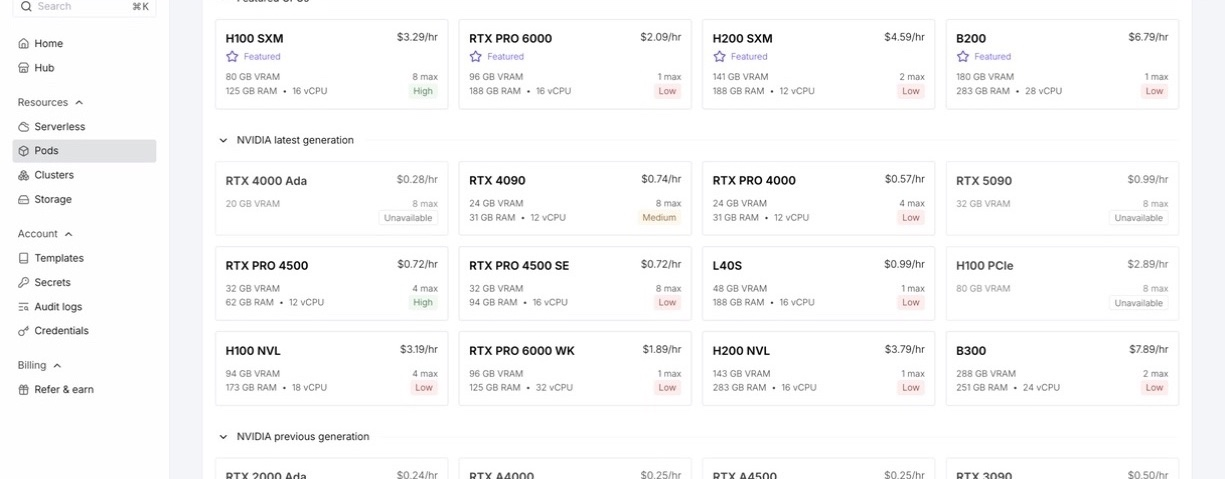



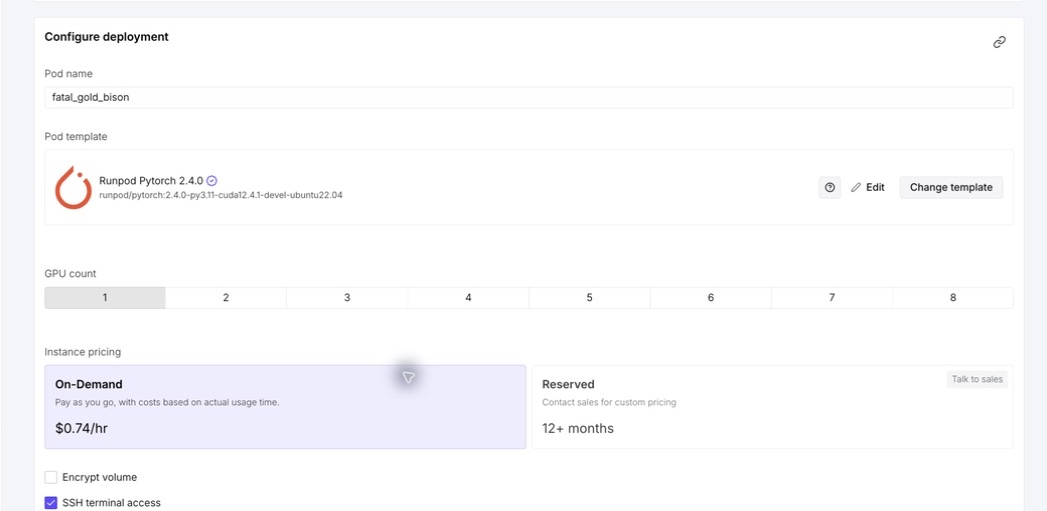

`Configure deployment`확인

1. `Pod template`에서 PyTorch·Python·CUDA version을 확인한다.
2. 첫 실습은 `GPU count=1`, `On-Demand`를 사용한다.
3. JupyterLab 접속에 필요한 HTTP service가 활성화되었는지 확인한다.
4. 화면 아래의 storage 설정에서 Volume disk가 `/workspace`에 연결되는지 확인한다.
5. `Deploy On-Demand`를 누르기 직전에 예상 GPU·storage 비용을 다시 확인한다.

캡처에서는 Pod를 실제로 배포하지 않았다. 실습자는 자신의 가격·가용성·CUDA 호환 경고를 확인한 뒤 배포한다.


## 실행 중인 Pod에 연결하고 Notebook 만들기

Pod 생성이 끝나면 이름 옆 상태 표시가 초록색으로 바뀐다. `Connect`를 열고 `HTTP Services → JupyterLab`을 선택한다.

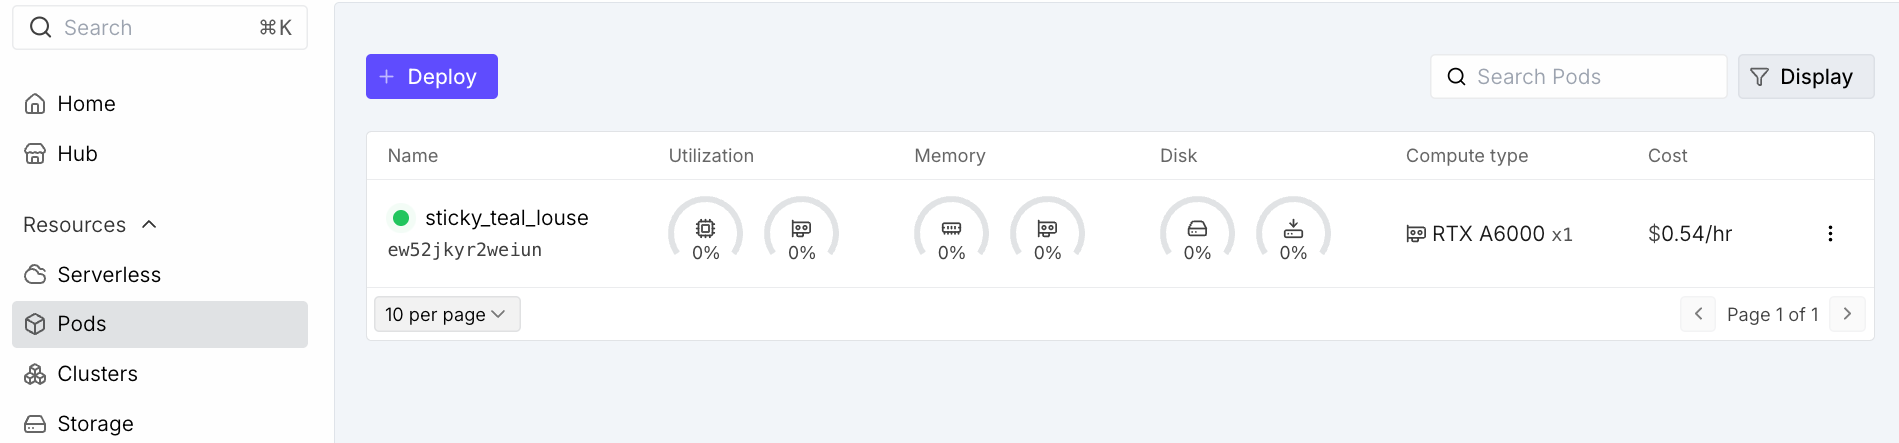

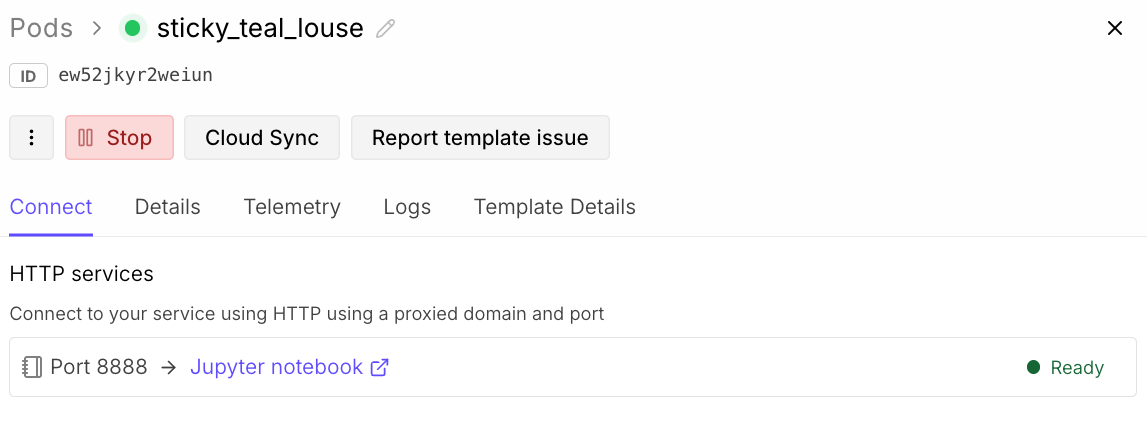
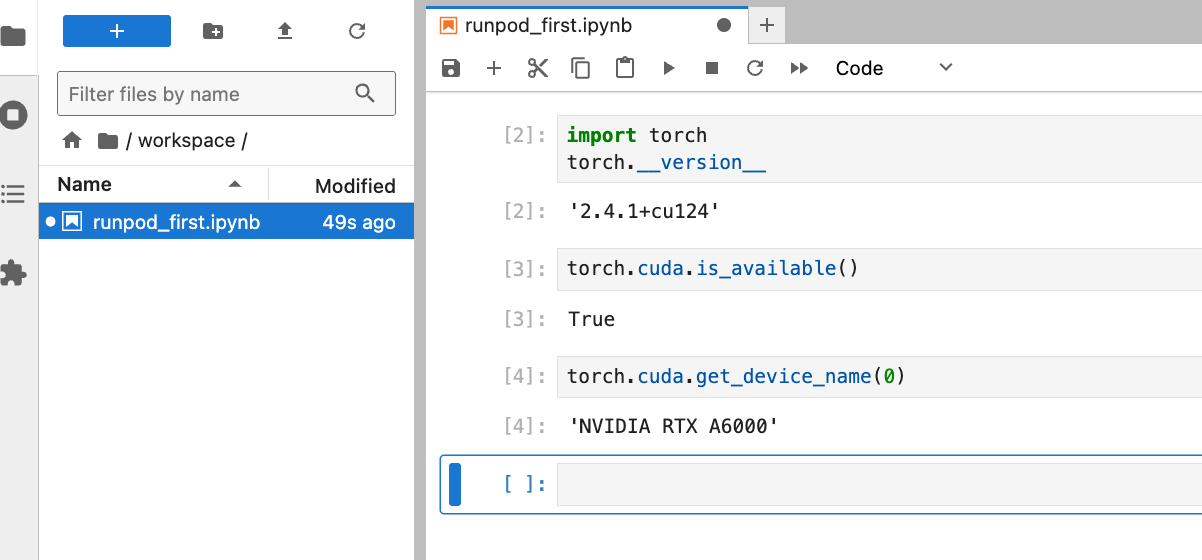
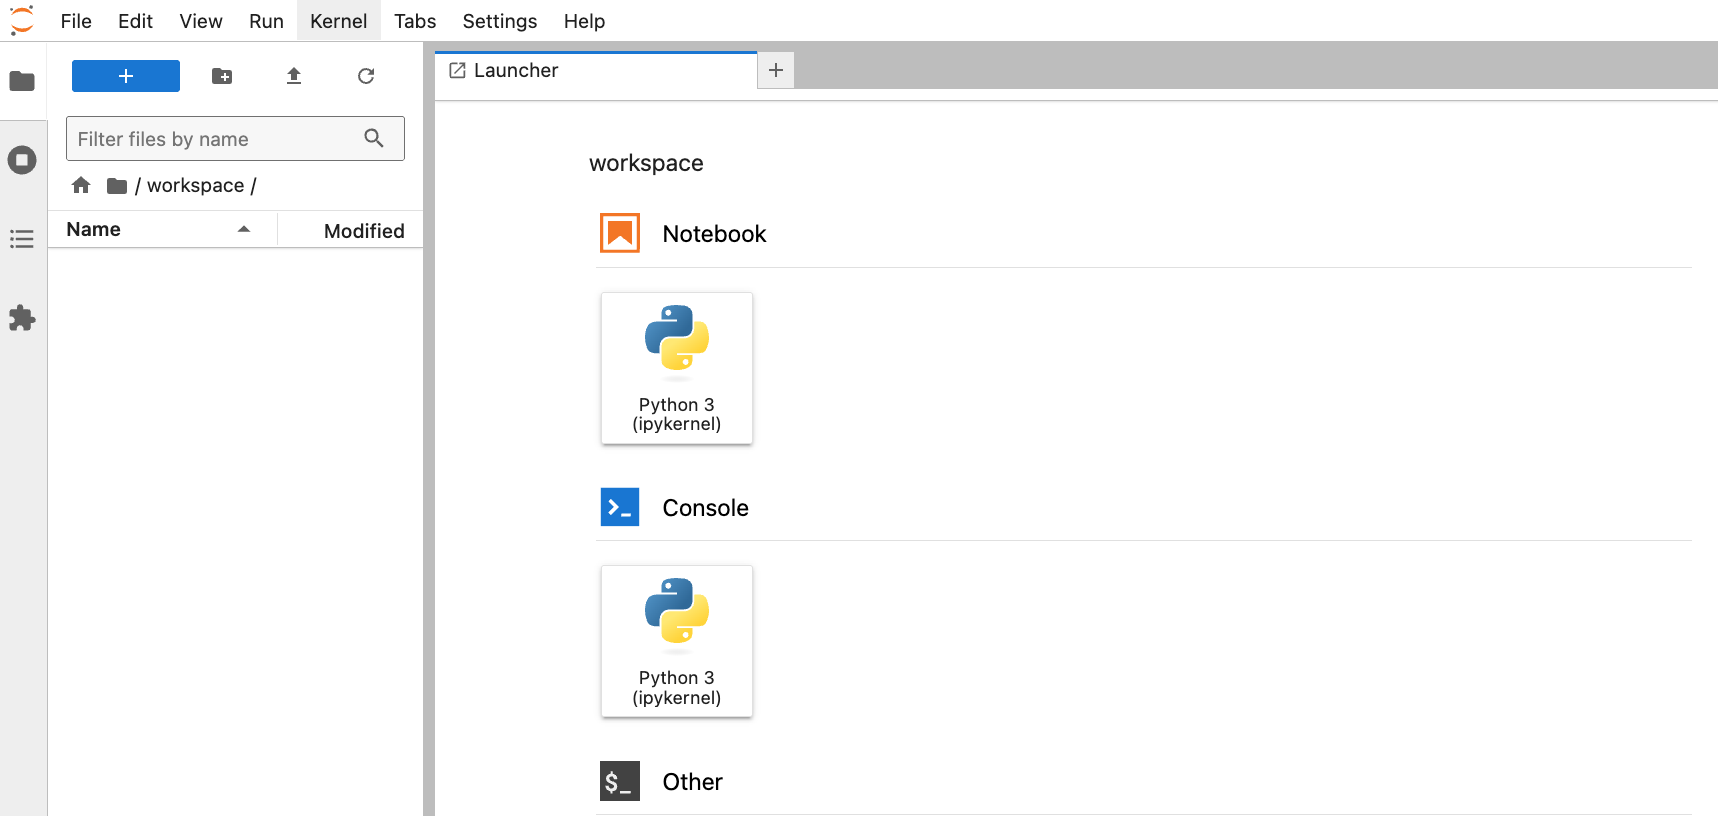


JupyterLab이 열리면 왼쪽 파일 브라우저가 `/workspace`를 가리키는지 확인한다. Notebook, 데이터와 학습 결과는 Stop 뒤에도 유지해야 하므로 `/workspace` 아래에서 작업한다.

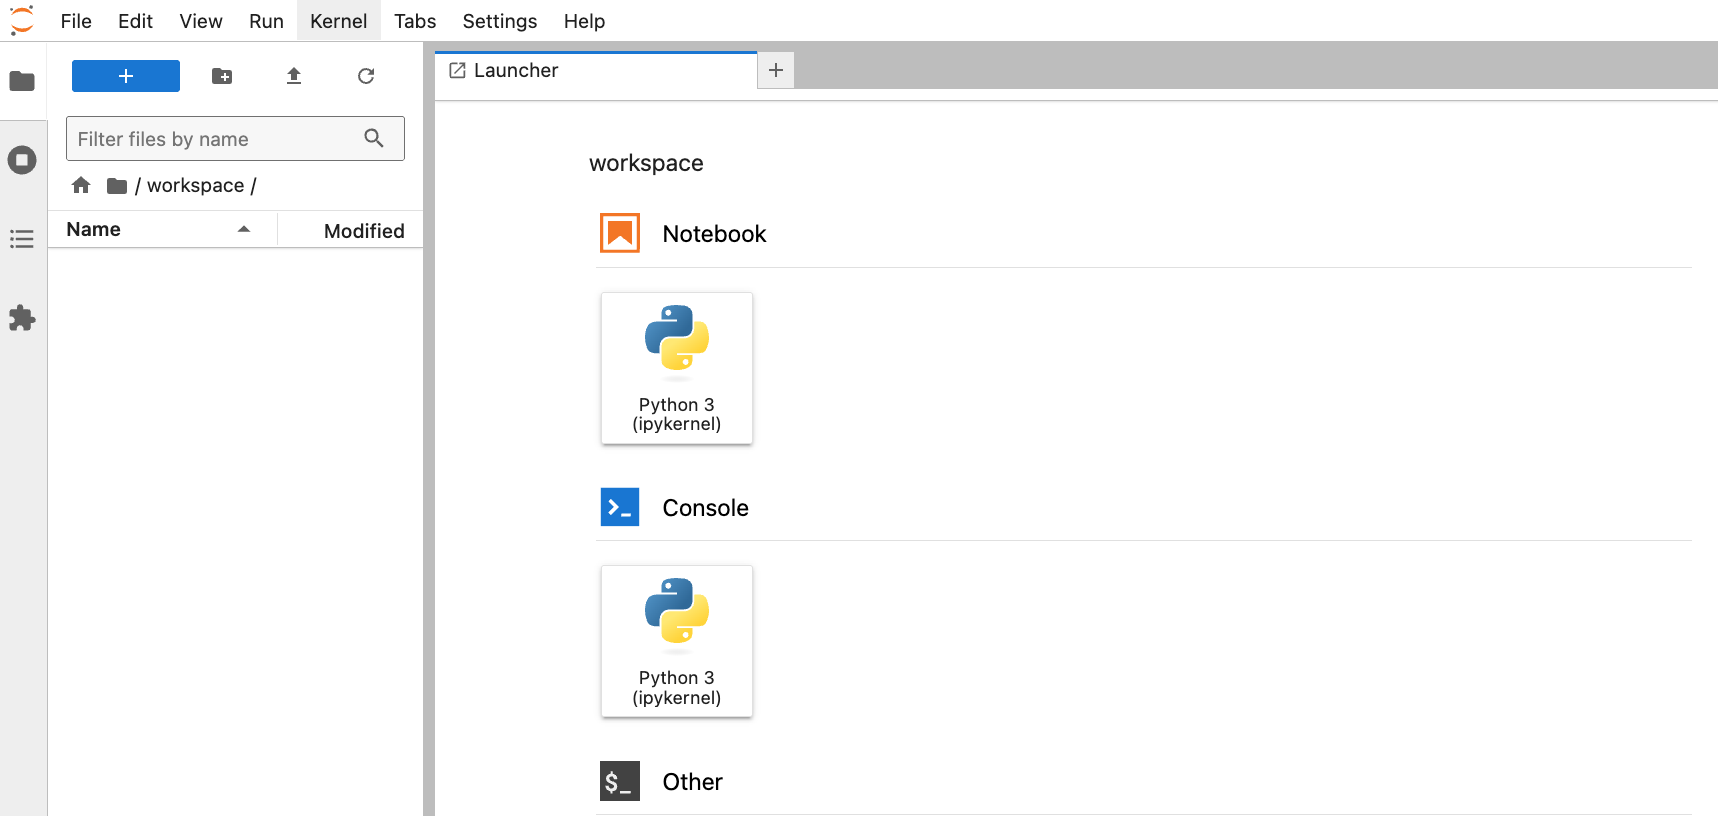

Launcher에서 `Notebook → Python`을 선택해 새 `.ipynb` 파일을 만든다. 파일 이름을 `runpod_first.ipynb`로 변경하고 아래 환경 확인 셀을 실행한다. 작업이 끝나면 Notebook과 필요한 결과를 `/workspace`에 저장하고, Pod를 Terminate하기 전에는 로컬에도 내려받는다.

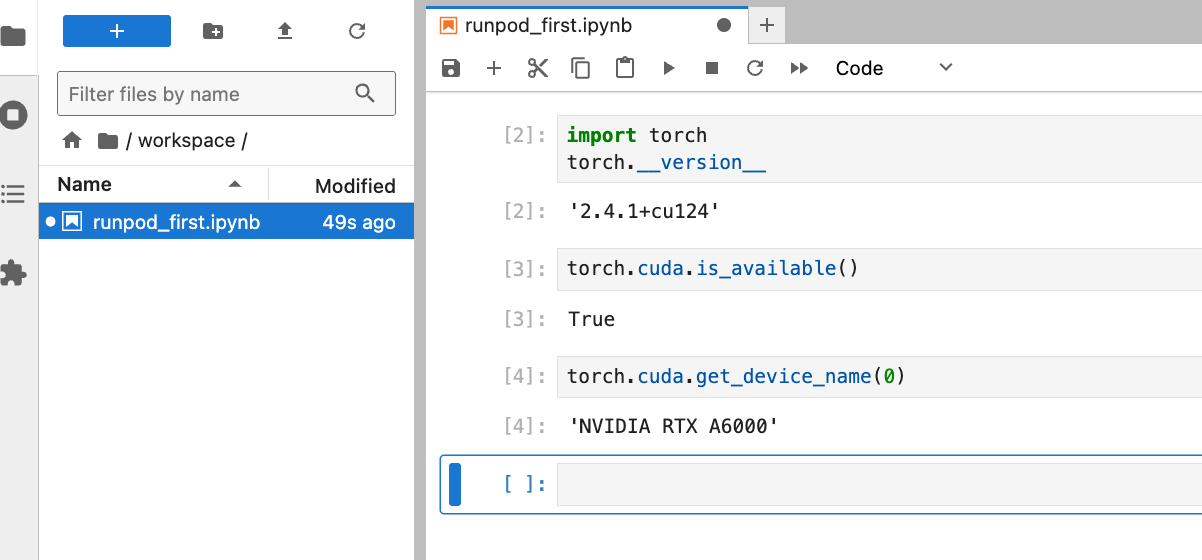

Jupyter URL과 token은 인증 정보가 될 수 있으므로 채팅·화면 캡처·Git에 남기지 않는다.


## 인스턴스 정지, 제거

사용하지 않는 Pod는 보존할 파일과 storage 종류를 확인한 뒤 Stop하거나 Terminate한다.

- **Stop**: GPU 할당과 GPU 비용은 멈춘다. `/workspace`의 Pod Volume은 유지되고 storage 비용은 계속 발생하지만, Container disk의 패키지·임시 파일은 사라질 수 있다.
- **Terminate**: Pod와 연결된 일반 Volume은 삭제되어 복구할 수 없다. Network volume은 Pod와 독립적이므로 별도로 삭제할 때까지 데이터와 비용이 유지될 수 있다.


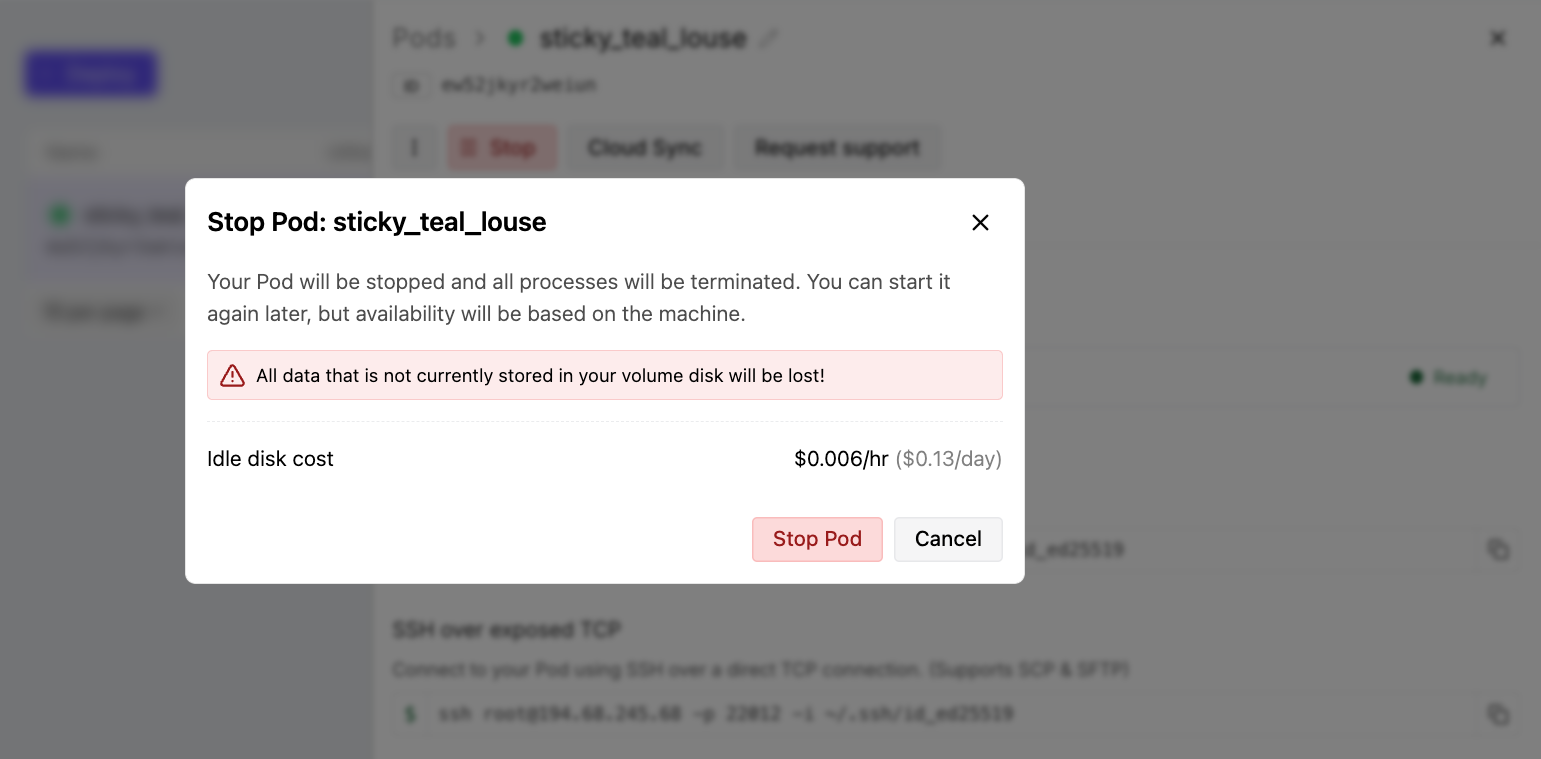

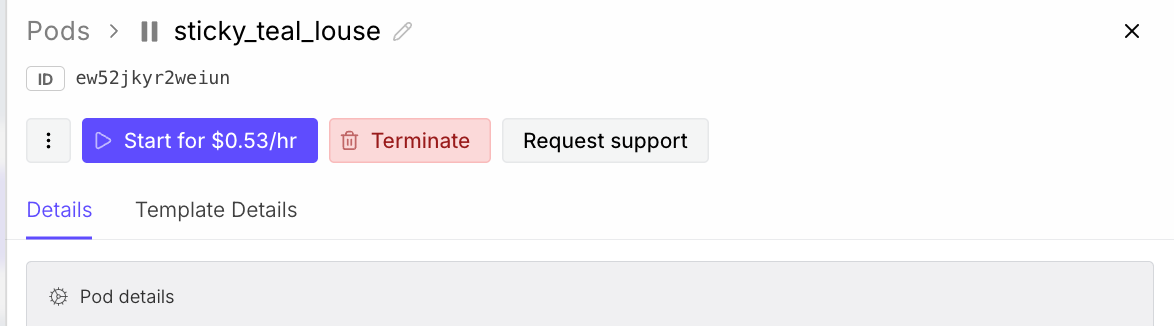

## 주의 사항
- Pod를 Stop하거나 Terminate하면 GPU 할당이 해제되므로 다른 사용자가 해당 GPU를 사용할 수 있다.
- Pod를 다시 시작할 때 같은 GPU의 재고가 부족하면 `Out of capacity` 또는 `GPU unavailable` 오류가 발생할 수 있다.
- 재시작 전에 notebook·adapter·checkpoint가 `/workspace` 또는 외부 저장소에 있는지 확인한다.
